In [1]:
import numpy as np

import xarray as xr
from xarray.coders import CFDatetimeCoder
time_coder = CFDatetimeCoder(use_cftime=True)

import csv

import os
from tqdm import tqdm

from matplotlib import pyplot as plt

from scipy import ndimage
import geopandas as gpd
from shapely.geometry import Point
import glob

from collections import defaultdict


### Setup

In [281]:
# This can be done in different ways but the idea is to lazy-load all forcing files (TF and Q)
cmip_dir = 'CESM2-WACCM'
cmip_file = 'CESM2-WACCM'

# ISMIP7 ocean forcings
directory = '/Users/dfelikso/Research/Data/ISMIP7/Forcing/GrIS/' + cmip_dir + '/*'
oceanTF_ds = xr.open_mfdataset(directory + '/TF/v1/TF_' + cmip_file + '_*_????.nc', decode_times=time_coder, chunks='auto')
runoff_ds  = xr.open_mfdataset(directory + '/SDBN1/Q/v1/Q_' + cmip_file + '_*_SDBN1_????.nc', decode_times=time_coder, chunks='auto')

# Submerged area
submergedarea_ds = xr.open_dataset('basin_submerged_area_ismip.nc')

# BedMachine
bed_ds = xr.open_dataset('/Users/dfelikso/Research/Data/GreenlandBed/MCbed/BedMachineGreenland-v5/BedMachineGreenland-v5.nc')

# Drainage sectors
sectors_ds = xr.open_dataset('/Users/dfelikso/Research/Data/Ice Sheet Drainage Basins/GrIS_Basins_Mouginot_extended_e01000m_v1.nc')

# Glacier locations
glacier_csv = 'combined_glacierIDs_modified.txt'


### Define function to calculate melt rate

In [268]:
melt_rate_params = dict()
melt_rate_params['A']     = 0.0003
melt_rate_params['alpha'] = 0.39
melt_rate_params['B']     = 0.15
melt_rate_params['beta']  = 1.18

def melt_rate(q_sg, h, TF, params=melt_rate_params, k=1.64):
   q_m = k * (params['A'] * h * q_sg**params['alpha'] + params['B']) * TF**params['beta']
   return q_m

### Interpolate bed and submergedarea to the ISMIP grid

In [47]:
bed_interp_ds = bed_ds.interp_like(oceanTF_ds)
bed_interp_ds = bed_interp_ds.where(bed_interp_ds.bed < 0.)

submergedarea_interp_ds = submergedarea_ds.interp_like(oceanTF_ds)


### Calculate (linear) q_m on the ISMIP grid

Very important: runoff must be converted to a linear rate by dividing by the glacier's submerged area

AND

it must be converted to units of m d-1 because that's how the constants in the Rignot parameterization are setup.

In [269]:
# Convert Q (m3 s-1) to q (m d-1) by dividing y submerged area and converting the time units
Q_sg = runoff_ds.Q
q_sg = 86400. * Q_sg / submergedarea_ds.submergedarea # m d-1

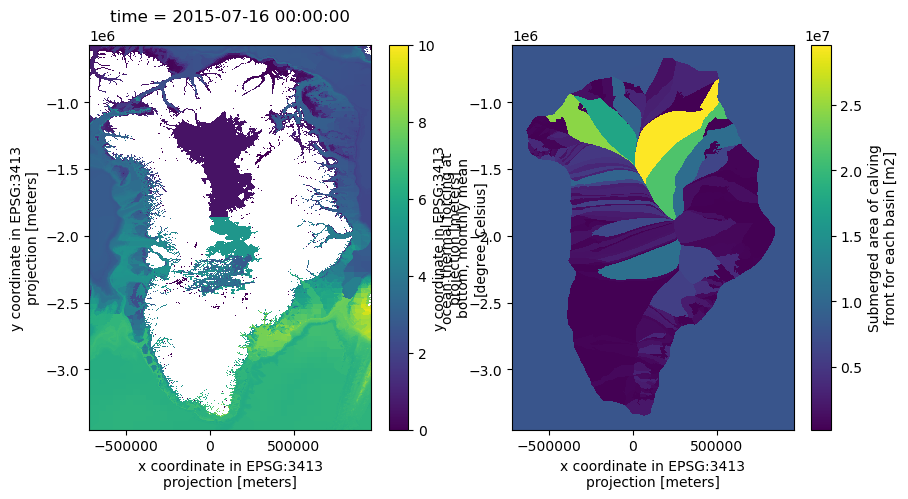

In [304]:
# Calculate the gridded melt rate
q_m_da = melt_rate(q_sg, -bed_interp_ds.bed, oceanTF_ds.TF) # m d-1

# Check a plot of gridded melt rate and submerged area (interpolated to the ISMIP grid)
fig, ax = plt.subplots(1,2,figsize=(10,5))
oceanTF_ds.TF.isel(time=6).plot(ax=ax[0], vmin=0, vmax=10)
submergedarea_interp_ds.submergedarea.plot(ax=ax[1])


### Aggregate linear melt rates (q_m) into melt flux (Q_m)
This is done by masking q_m to just the "terminus" grid cells, which are the ice grid cells that are neighboring the ocean.

In the processing below, an assumption must be made about the orientation of the terminus within a grid cell. This is needed in order to get the submerged area of the terminus. Three different assumptions are made to roughly bound the error in the calculation:
- "lower" bound = assume that the terminus is oriented either exactly vertically or horizontally; thus, the terminus length = dx
- "upper" bound = assume that the terminus is oriented along both the x and y faces of a grid cell; thus the terminus length = 2*dx
- "baseline"    = assume that the terminus is oriented diagonally within a grid cell; thus the terminus length = sqrt(2)*dx


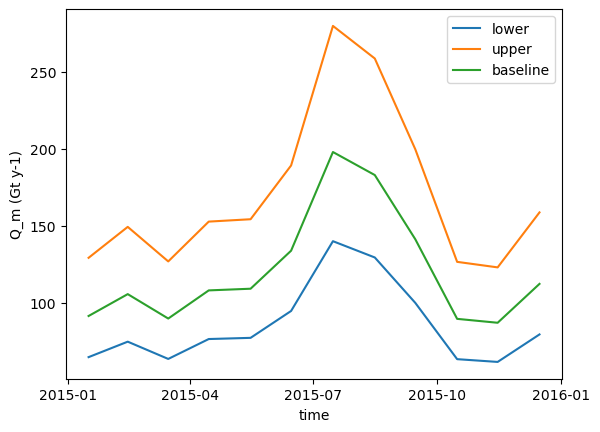

In [308]:
# Find grid cells with ocean
ocean_mask = bed_interp_ds.mask == 0

# Dilate the ocean mask, which buffers the mask by 1 pixel
dilated_mask = ndimage.binary_dilation(ocean_mask)

# Find grid cells with ice grounded below sea level in the buffered ocean mask, 
# thus identifying the grid cells that have ice next to ocean
terminus_mask = (dilated_mask) & (bed_interp_ds.mask == 2) & (bed_interp_ds.bed < 0)

# Within the terminus grid cells, estimate the submerged area in multiple ways:
#  1.) Assume that the terminus is oriented either exactly vertically or horizontally; thus, the terminus length = dx
dl_lower = bed_interp_ds.x[1]-bed_interp_ds.x[0]
#  2.) Assume that the terminus is oriented diagonally within a grid cell; thus the terminus length = sqrt(2)*dx
dl_baseline = np.sqrt(2) * (bed_interp_ds.x[1]-bed_interp_ds.x[0])
#  3.) Assume that the terminus is oriented along both the x and y faces of a grid cell; thus the terminus length = 2*dx
dl_upper = 2 * (bed_interp_ds.x[1]-bed_interp_ds.x[0])

# NOTE: The "upper" bound may not actually results in realistically high values because actual termini may be much more sinuous,
#       resulting in a length that is even higher than 2*dx.

# Calculate melt flux (Q_m) across all terminus faces, sum for all grid cells, and plot the time series
for dl in [dl_lower, dl_upper, dl_baseline]:
    submergedarea = -dl * bed_interp_ds.bed.where(terminus_mask)
    Q_m = submergedarea * q_m_da # m3 d-1
    # Convert the units to Gt/yr to get a more intuitive number
    Q_m = 365 * 1000. * Q_m * 1e-12 # Gt y-1

    Q_m.sum(dim=['x','y']).plot()

plt.ylabel('Q_m (Gt y-1)')
plt.legend(('lower','upper','baseline'))


## Sample by sector
Subset the calculation for Q_m above into sectors

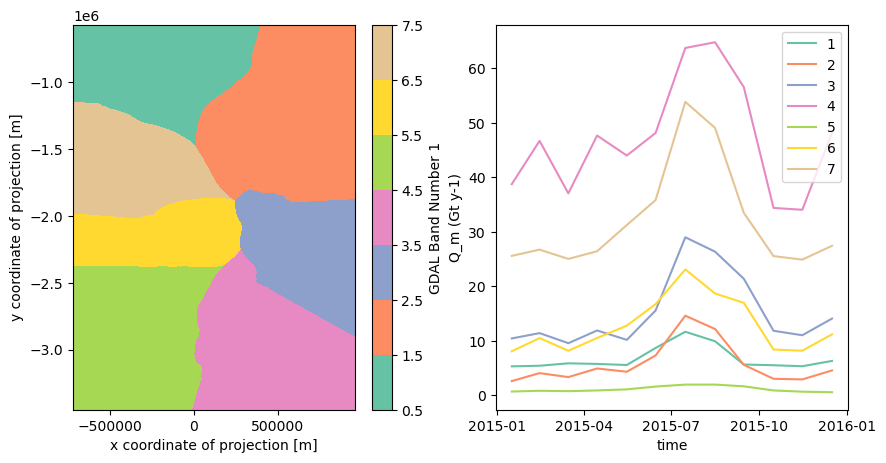

In [330]:
fig, ax = plt.subplots(1,2, figsize=(10,5))

colors_7 = plt.cm.Set2.colors[:7]
sectors_ds.ID.plot(levels=np.arange(0.5,8.5), ax=ax[0], colors=colors_7) #, vmin=0.5, vmax=7.5)

for i, ID in enumerate(np.unique(sectors_ds.ID)):
    Q_m.where(sectors_ds.ID == ID).sum(dim=['x','y']).plot(c=colors_7[i], ax=ax[1], label=int(ID))

ax[1].set_ylabel('Q_m (Gt y-1)')
ax[1].legend()


## Sample the quantities at glacier locations
This is a sanity check for the calculations above. It should yield an overestimated melt flux because the sampled q_m is taken at roughly the middle of each glacier, which is typically close to the deepest grounded portion. Thus, this gives the ~highest linear melt rate for the glacier. When multiplied by the submergedarea, this will yield an overestimate of the melt flux for the glacier.

In [278]:
csv_header = True
x_col  = 1
y_col  = 2
id_col = 0

# Read outlet glacier x/y
with open(glacier_csv) as csv_file:
    delimiter = ' '
    csv_reader = csv.reader(csv_file, delimiter=delimiter)
    if csv_header: next(csv_reader, None)
    
    glaciers = list()
    for row in csv_reader:
        x = float(row[x_col])
        y = float(row[y_col])
        glacier_id = row[id_col]
        if not isinstance(glacier_id, str):
            glacier_id = '{:4.0f}'.format(glacier_id)
        glaciers.append([glacier_id, x, y])

def sample_da_by_glacier(da, glaciers):
    if 'time' in da.coords:
        z = np.empty((len(glaciers),len(da.time)))
    else:
        z = np.empty((len(glaciers)))
        
    for i, glacier in enumerate(tqdm(glaciers, ncols=60)):
        id_glacier= glacier[0]
        x_glacier = glacier[1]
        y_glacier = glacier[2]
        
        if 'time' in da.coords:
            z[i,:] = da.sel(x=x_glacier, y=y_glacier, method='nearest').values
        else:
            z[i] = da.sel(x=x_glacier, y=y_glacier, method='nearest').values
            
    return z
    

In [332]:
# Sample q_m, submerged area, and sector per glacier
q_m_glaciers = sample_da_by_glacier(q_m_da, glaciers)
sa_glaciers = sample_da_by_glacier(submergedarea_ds.submergedarea, glaciers)
sectors_glaciers = sample_da_by_glacier(sectors_ds.ID, glaciers)


100%|███████████████████| 277/277 [00:00<00:00, 3611.37it/s]


Text(0, 0.5, 'Q_m (Gt y-1)')

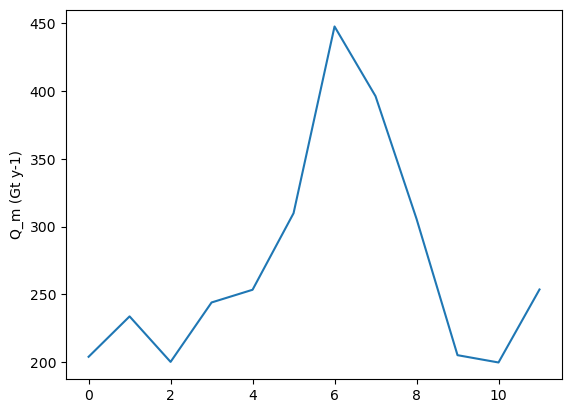

In [334]:
Q_m_total = np.zeros((q_m_glaciers.shape[1],))

for i in range(277):
    if ~np.any(np.isnan(q_m_glaciers[i,:])):
        Q_m_total += q_m_glaciers[i,:] * sa_glaciers[i]

Q_m_total = 365. * 1000. * Q_m_total * 1e-12 # Gt y-1

plt.plot(Q_m_total)
plt.ylabel('Q_m (Gt y-1)')


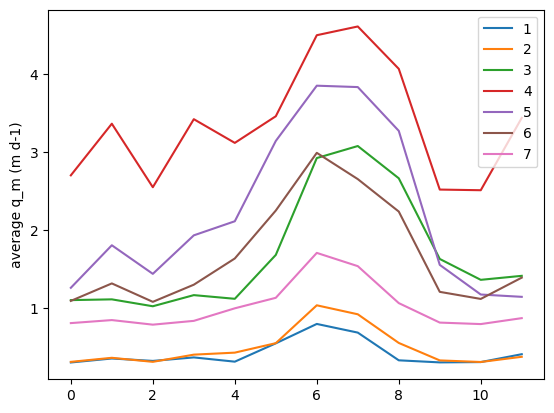

In [342]:
for ID in np.unique(sectors_ds.ID):
    q_m_total = np.zeros((q_m_glaciers.shape[1],))
    n = 0

    for i in range(277):
        if sectors_glaciers[i] == ID and ~np.any(np.isnan(q_m_glaciers[i,:])):
            q_m_total += q_m_glaciers[i,:]
            n += 1

    q_m_average = q_m_total / n # m d-1
    plt.plot(q_m_average, label=int(ID))

plt.ylabel('average q_m (m d-1)')
plt.legend()


## Old method - do not use!

In [ ]:
for glacier in tqdm(glaciers):
    id_glacier= glacier[0]
    x_glacier = glacier[1]
    y_glacier = glacier[2]
    
    nc_filename   = 'netcdfs/glacier' + id_glacier + '_q_m.nc'
    if os.path.isfile(nc_filename): continue

    # b = bed_ds['bed'].sel(x=x_glacier, y=y_glacier, method='nearest').values
    xidx = np.abs(bed_ds.x-x_glacier).argmin()
    yidx = np.abs(bed_ds.y-y_glacier).argmin()
    b = bed_ds['bed'].isel(x=xidx, y=yidx).values
    # sa = submergedarea_ds['submergedarea'].sel(x=x_glacier, y=y_glacier, method='nearest').values
    xidx = np.abs(submergedarea_ds.x-x_glacier).argmin()
    yidx = np.abs(submergedarea_ds.y-y_glacier).argmin()
    sa = submergedarea_ds['submergedarea'].isel(x=xidx, y=yidx).values

    # TF = oceanTF_ds['TF'].sel(x=x_glacier, y=y_glacier, method='nearest').values
    xidx = np.abs(oceanTF_ds.x-x_glacier).argmin()
    yidx = np.abs(oceanTF_ds.y-y_glacier).argmin()
    TF = oceanTF_ds['TF'].isel(x=xidx, y=yidx).values
    TF_da = xr.DataArray(TF, coords={'time': oceanTF_ds['time']}, dims='time')
    TF_da.attrs['long_name'] = 'TF'
    TF_da.attrs['units'] = 'degC'

    # Q = runoff_ds['Q'].sel(x=x_glacier, y=y_glacier, method='nearest').values * 86400.
    xidx = np.abs(runoff_ds.x-x_glacier).argmin()
    yidx = np.abs(runoff_ds.y-y_glacier).argmin()
    Q = runoff_ds['Q'].isel(x=xidx, y=yidx).values
    q = Q / sa
    q_da = xr.DataArray(q, coords={'time': runoff_ds['time']}, dims='time')
    q_da.attrs['long_name'] = 'q'
    q_da.attrs['units'] = 'm d-1'
    q_da.attrs['submergedarea'] = sa
    
    q_m = melt_rate(q, -b, TF)
    
    q_m_da = xr.DataArray(q_m, coords={'time': oceanTF_ds['time']}, dims='time')
    q_m_da.attrs['long_name'] = 'q_m'
    q_m_da.attrs['units'] = 'm d-1'
    
    ds = xr.Dataset({'TF': TF_da, 'q': q_da, 'q_m': q_m_da})
    ds.attrs['x'] = x_glacier
    ds.attrs['y'] = y_glacier
    ds.attrs['b'] = b
    ds.to_netcdf(nc_filename)


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Loop through ocean sectors
glacier_basins = defaultdict(list)

fig_map, ax_map = plt.subplots()

for basin in range(1,8):
    fig_basin, ax_basin = plt.subplots(1,2,figsize=(12,4))
    
    gdf = gpd.read_file('ocean_regions/ocean_region_{:1d}.shp'.format(basin))
    
    poly_x = gdf.get_coordinates().x
    poly_y = gdf.get_coordinates().y

    # Plot the polygon outline
    # ax_basins.plot(poly_x, poly_y) # outline
    ax_map.fill(poly_x, poly_y, alpha=0.3, label='basin {:d}'.format(basin)) # fill
    
    q_m_all_glaciers_within_basin = np.zeros( (5412,) )
    Q_m_all_glaciers_within_basin = np.zeros( (5412,) )
    
    for glacier_ncfile in sorted(glob.glob('netcdfs/*nc')):
        q_m_ds = xr.open_dataset(glacier_ncfile)
        
        is_within_series = gdf.geometry.contains(Point(q_m_ds.x, q_m_ds.y))
        if is_within_series.any():
            if np.any(q_m_ds['q_m'].values < 0.):
                print('Warning: Glacier {:s} has q_m values < 0 !'.format(glacier_ncfile.split('/')[1].split('_')[0].replace('glacier','')))
                if q_m_ds.b > 0.:
                    print('   ... but b > 0.')
                    print('   ... so we are not including this glacier in plots and stats!')
            else:
                glacier_basins[basin].append(glacier_ncfile.split('/')[1].split('_')[0].replace('glacier',''))
                for iax, time_slice in enumerate([slice(0, 3000), slice(3000, 5412)]):
                    q_m_ds['q_m'].isel(time=time_slice).plot(ax=ax_basin[iax], color='k', alpha=0.05)

                if np.sum(q_m_all_glaciers_within_basin) == 0:
                    if ~np.isnan(q_m_ds['q_m'].values).all():
                        q_m_all_glaciers_within_basin  = q_m_ds['q_m']
                        Q_m_all_glaciers_within_basin  = q_m_ds['q_m'] * q_m_ds.q.submergedarea
                else:
                    if ~np.isnan(q_m_ds['q_m'].values).all():
                        q_m_all_glaciers_within_basin += q_m_ds['q_m']
                        Q_m_all_glaciers_within_basin += q_m_ds['q_m'] * q_m_ds.q.submergedarea

        q_m_ds.close()

    q_m_mean = q_m_all_glaciers_within_basin / len(glacier_basins[basin])
    # Q_m_mean = Q_m_all_glaciers_within_basin / len(glacier_basins[basin])
    for iax, time_slice in enumerate([slice(0, 3000), slice(3000, 5412)]):
        q_m_mean_sel = q_m_mean.isel(time=time_slice)
        q_m_mean_sel.sel(time=q_m_mean_sel.time.dt.month.isin([6, 7, 8])).plot(ax=ax_basin[iax], color='r')
    
    # Calculate statistics per time slice
    if basin == 1:
        print('                       ', end='', flush=True)
        for time_slice in [(1980, 2000), (2080, 2100), (2180, 2200), (2280, 2300)]:
            if basin == 1: print('{:d}-{:d}  '.format(time_slice[0], time_slice[1]), end='', flush=True)
        print('')
    print('Basin {:d} (q_m) [m/d]  '.format(basin), end='', flush=True)
    for time_slice in [(1980, 2000), (2080, 2100), (2180, 2200), (2280, 2300)]:
        start_date = cftime.DatetimeNoLeap(time_slice[0], 1, 1)
        end_date = cftime.DatetimeNoLeap(time_slice[1], 12, 31)
        print('   {:8.3f}'.format(q_m_mean.sel(time=slice(start_date, end_date)).mean('time').values), end='', flush=True)
    print('')
    print('Basin {:d} (Q_m) [km3/a]'.format(basin), end='', flush=True)
    for time_slice in [(1980, 2000), (2080, 2100), (2180, 2200), (2280, 2300)]:
        start_date = cftime.DatetimeNoLeap(time_slice[0], 1, 1)
        end_date = cftime.DatetimeNoLeap(time_slice[1], 12, 31)
        print('   {:8.1f}'.format(Q_m_all_glaciers_within_basin.sel(time=slice(start_date, end_date)).mean('time').values * (360 / 1e9)), end='', flush=True)
    print('')

    ax_basin[0].set_ylim(-0.5, 15.)
    ax_basin[1].set_ylim(-5.0, 80.)
    fig_basin.savefig('plots/q_m_basin{:d}.pdf'.format(basin), bbox_inches='tight')

ax_map.set_aspect('equal')
ax_map.legend(labelspacing=0, loc='lower right')
fig_map.savefig('plots/basin_map.pdf', bbox_inches='tight')
